# sc-GEM Analysis

In [140]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

embedding_dir = f'./embeddings/hgnn/sc_GEM-bce'

DATA = 'sc_GEM'

def load_labels():
    cell_stage = np.array(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))[0]
    return cell_stage

def check_labels(cell_stage, cell_ids):
    for label, id in zip(cell_stage, cell_ids):
        if label not in id:
            print('Bad id', id, 'label', label)
            return False
    return True

In [141]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.array(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))[0]

metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [142]:
gene_embeddings.shape, cell_embeddings.shape

((61, 64), (224, 64))

In [143]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_2', 'BJ_44', 'BJ_11', 'BJ_14', 'BJ_19', 'BJ_41', 'BJ_22',
       'BJ_1', 'BJ_34', 'BJ_8', 'BJ_4', 'BJ_21', 'BJ_18', 'BJ_15',
       'BJ_24', 'BJ_31', 'BJ_35', 'BJ_13', 'BJ_12', 'BJ_40', 'BJ_17',
       'BJ_29', 'BJ_5', 'BJ_9', 'BJ_23', 'BJ_25', 'BJ_3', 'BJ_28',
       'BJ_37', 'BJ_32', 'BJ_26', 'BJ_27', 'BJ_7', 'BJ_46', 'BJ_43',
       'd8_8', 'd8_19', 'd8_34', 'd8_25', 'd8_16', 'd8_3', 'd8_13',
       'd8_22', 'd8_27', 'd8_26', 'd8_43', 'd8_40', 'd8_35', 'd8_5',
       'd8_38', 'd8_12', 'd8_14', 'd8_17', 'd8_44', 'd8_1', 'd8_29',
       'd8_37', 'd8_2', 'd8_21', 'd8_10', 'd8_30', 'd8_32', 'd8_7',
       'd8_18', 'd8_9', 'd8_39', 'd8_24', 'd8_33', 'd8_23', 'd8_11',
       'd8_46', 'd8_28', 'd8_45', 'd8_4', 'd8_41', 'd16T-_1', 'd16T-_4',
       'd16T-_8', 'd16T-_5', 'd16T-_7', 'd16T-_12', 'd16T-_6', 'd16T-_16',
       'd16T-_2', 'd16T-_9', 'd16T-_11', 'd16T-_15', 'd16T-_10',
       'd16T+_15', 'd16T+_11', 'd16T+_13', 'd16T+_9', 'd16T+_28',
       'd16T+_7', 'd16T+_2', 'd16T+_

In [144]:
check_labels(cell_stage, cell_names)

True

In [145]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

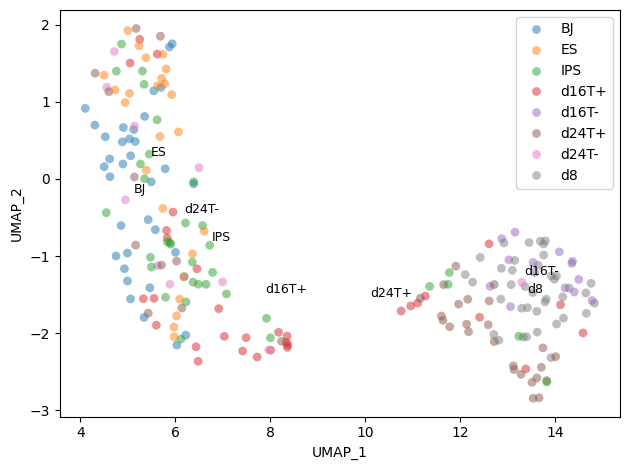

In [146]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage,
                hue_order=sorted(set(cell_stage)),
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")

# ---- 计算每个类的中心并标注 ----
df = pd.DataFrame({'UMAP_1': vec[:, 0], 'UMAP_2': vec[:, 1], 'label': cell_stage})
centroids = df.groupby('label')[['UMAP_1', 'UMAP_2']].mean()

for label, row in centroids.iterrows():
    plt.text(row['UMAP_1'], row['UMAP_2'], str(label),
             fontsize=9, ha='center', va='center',)
plt.tight_layout()

ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

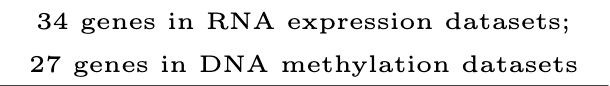

In [147]:
gene_embeddings.shape, len(gene_names)

((61, 64), 61)

In [148]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,-0.341919,0.519440,0.214049,-0.425273,-0.627631,-15.993104,0.593824,-0.494543,0.384512,0.211129,...,0.046750,-0.405843,0.187266,-0.119827,-0.094171,1.669857,-0.046471,-0.170508,0.577700,0.352997
1,0.100992,-0.373343,0.441652,-0.198613,0.746913,-14.616501,0.736561,-0.137169,0.476141,-0.887755,...,-0.467216,-0.204670,-0.568955,-0.088680,-0.046981,-1.661666,0.809780,-0.687881,-0.154916,-0.495510
2,0.991363,1.311278,0.345861,-0.428183,-0.304317,-13.880039,0.390947,0.285733,0.962925,0.179337,...,1.433460,1.517082,0.615937,1.645810,1.122692,-0.744938,1.170970,0.043306,1.263945,1.625566
3,0.281180,-0.012665,-0.429738,-0.942955,-0.023046,-15.391411,0.617901,-1.687633,-0.634012,-0.333742,...,0.768335,0.934344,0.357812,0.812230,0.785621,0.543737,0.378348,0.416750,-1.029997,0.493978
4,-0.801872,-0.583972,-0.562887,-0.773138,-0.358675,15.220126,-0.288587,0.262477,-0.921858,1.358403,...,-0.480045,-1.470817,-0.182028,-0.143047,-1.036100,0.458110,-0.630832,-0.249352,-0.246729,-0.660815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-0.181768,1.297956,1.467420,1.174514,1.768085,-5.444031,0.658744,0.726047,2.057230,-0.618401,...,0.111352,1.316368,-0.366936,0.221594,0.823013,-1.091230,0.351787,0.114745,-0.147067,0.045685
60,-0.028623,-1.231903,-0.320804,-0.822142,-0.650071,14.749237,-0.006316,1.170284,-1.000605,0.122138,...,0.024582,-0.121317,0.581691,-0.230303,-0.458314,1.133292,-0.126390,-0.020930,-0.102579,0.051801
61,0.698044,1.047363,0.421362,0.035502,1.171704,-12.974339,0.618289,0.255763,0.966821,-0.721638,...,0.364101,0.651000,-0.658268,-0.367600,0.241499,-0.963665,0.160211,-0.285310,0.033894,0.247239
62,-0.500168,-1.774023,-0.925872,-1.187901,-0.564146,4.620000,0.044968,0.451226,-1.981130,1.579235,...,-0.306999,-0.908825,0.996818,-0.603223,-0.465503,2.198864,-0.322896,-0.481551,-0.015218,-0.332977


In [149]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [150]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

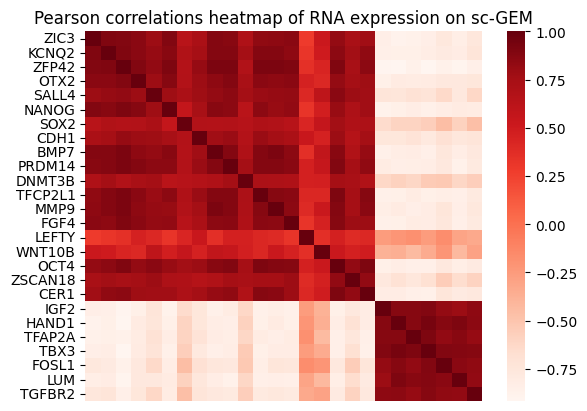

In [151]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [152]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

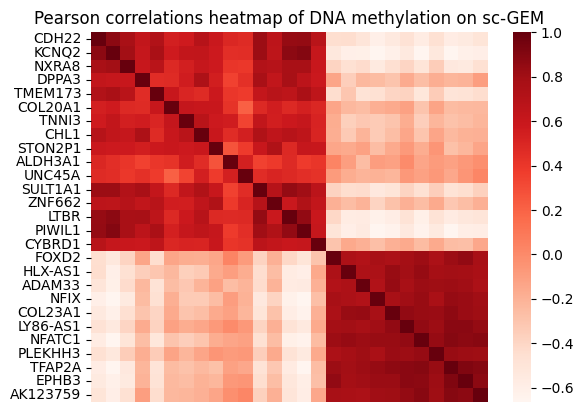

In [153]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [154]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [155]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [156]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [157]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [158]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [159]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [160]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [161]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,5.341898
1,BJ,TFAP2A,6.871538
2,BJ,TFAP2A,6.025817
3,BJ,TFAP2A,6.129010
4,BJ,TFAP2A,6.661609
...,...,...,...
1115,ES,TGFBR2,4.129641
1116,ES,TGFBR2,5.089085
1117,ES,TGFBR2,5.305641
1118,ES,TGFBR2,6.484076


Text(0, 0.5, 'Projection value')

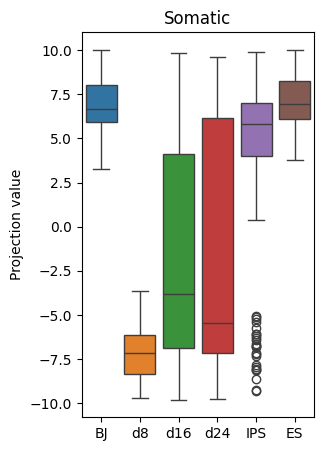

In [162]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [163]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,-6.033779
1,BJ,ZIC3,-6.813978
2,BJ,ZIC3,-5.899561
3,BJ,ZIC3,-6.092303
4,BJ,ZIC3,-6.535451
...,...,...,...
4251,ES,CER1,-5.456927
4252,ES,CER1,-4.995155
4253,ES,CER1,-6.656467
4254,ES,CER1,-7.000881


Text(0, 0.5, 'Projection value')

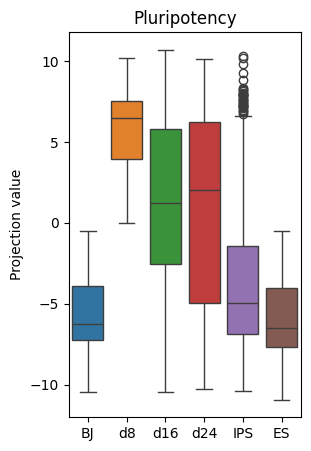

In [164]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [165]:
cell_stage_unique = sorted(set(cell_stage))
num_clusters = len(cell_stage_unique)
# Convert str to label id.
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage_unique)}
cell_stage_label = np.array([cell_stage_ids[y] for y in
                             cell_stage])

print(cell_stage_unique)
print('num_clusters', num_clusters)
print(cell_stage_ids)
print(np.min(cell_stage_label), np.max(cell_stage_label))

['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8']
num_clusters 8
{'BJ': 0, 'ES': 1, 'IPS': 2, 'd16T+': 3, 'd16T-': 4, 'd24T+': 5, 'd24T-': 6, 'd8': 7}
0 7


In [166]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, cell_stage)

{'NMI': 0.29451433730274734,
 'ARI': 0.15567492108235362,
 'FMI': 0.27114102694095227}

### Baselines

t-SNE, PCA, UMAP.

In [167]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [168]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [169]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009866714477539062
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

In [170]:
assert (create.df.index == cell_names).all().all()


In [171]:
features = create.df.values
features.shape

(224, 61)

In [172]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []
    k = num_clusters
    for name, method in baselines.items():
        print(name)
        if method is None:
            x = UMAP(n_components=dims).fit_transform(cell_embeddings)
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


### K-means performance

In [173]:
df_cluster = run_baselines(features, cell_embeddings, dims=3)

TSNE


NameError: name 'k_means' is not defined

Text(0, 0.5, '')

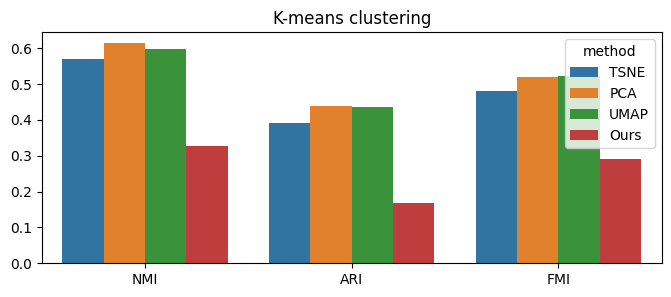

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

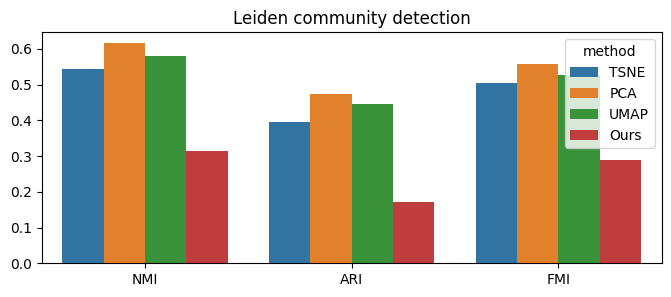

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')